Importing Libraries

In [12]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

Load Dataset

In [13]:
df = pd.read_csv("gold_price_data.csv")
df.head()

,Date,SPX,GLD,USO,SLV,EUR/USD
0,1/2/2008,1447.160034,84.860001,78.470001,15.180,1.471692
1,1/3/2008,1447.160034,85.570000,78.370003,15.285,1.474491
2,1/4/2008,1411.630005,85.129997,77.309998,15.167,1.475492
3,1/7/2008,1416.180054,84.769997,75.500000,15.053,1.468299
4,1/8/2008,1390.189941,86.779999,76.059998,15.590,1.557099


Data Cleaning and Preprocessing

In [14]:
df = df.dropna()  

features = ['SPX', 'USO', 'SLV', 'EUR/USD']
target = 'GLD'

df.columns = df.columns.str.strip()
X = df[features]
y = df[target]

Correlation Analysis

SPX        0.049345
USO       -0.186360
SLV        0.866632
EUR/USD   -0.024375
GLD        1.000000
Name: GLD, dtype: float64


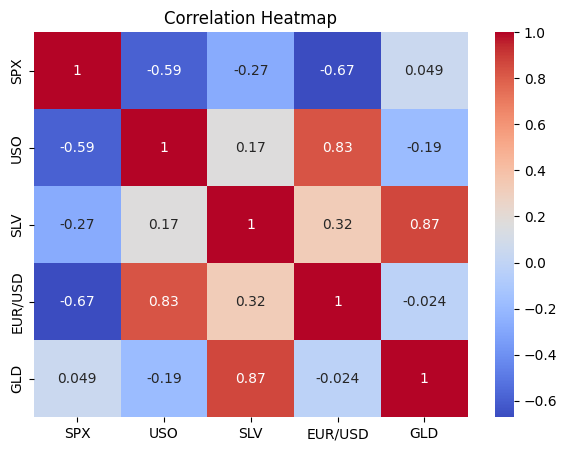


Strongest correlation with GLD: SLV


In [15]:
print(df[features + ['GLD']].corr()['GLD'])

plt.figure(figsize=(7,5))
sns.heatmap(df[features + ['GLD']].corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

strongest_corr = df[features].corrwith(df['GLD']).abs().idxmax()
print("\nStrongest correlation with GLD:", strongest_corr)

Splitting Data into Training and Testing Sets

In [16]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

Linear Regression Model

In [17]:
model = LinearRegression()
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

Printing Model Performance

In [18]:
r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("Linear Regression Model Performance:")
print(f"R² Score: {r2:.4f}")
print(f"MSE: {mse:.4f}")
print(f"RMSE: {np.sqrt(mse):.4f}")

Linear Regression Model Performance:
R² Score: 0.8976
MSE: 56.1656
RMSE: 7.4944


Residual Plot

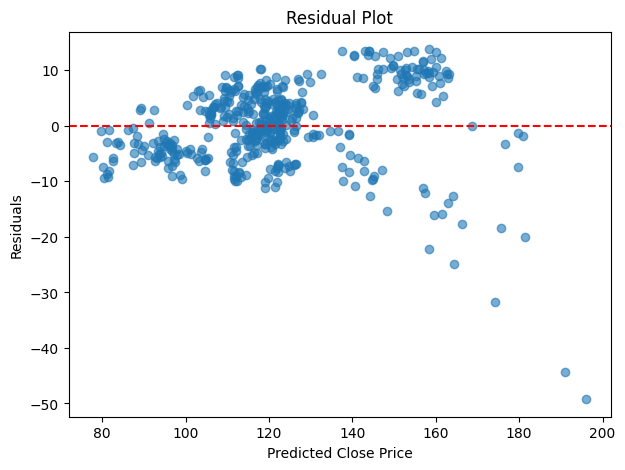

In [22]:
residuals = y_test - y_pred

plt.figure(figsize=(7,5))
plt.scatter(y_pred, residuals, alpha=0.6)
plt.axhline(0, color='red', linestyle='--')
plt.xlabel("Predicted Close Price")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

Printing Model Cooefficients


In [20]:
coef_df = pd.DataFrame({
    "Feature": features,
    "Coefficient": model.coef_
})

print("\nModel Coefficients:")
display(coef_df)


Model Coefficients:


,Feature,Coefficient
0,SPX,0.006605
1,USO,-0.250415
2,SLV,3.130634
3,EUR/USD,-10.883817


Visualizing Actual vs Predicted Data

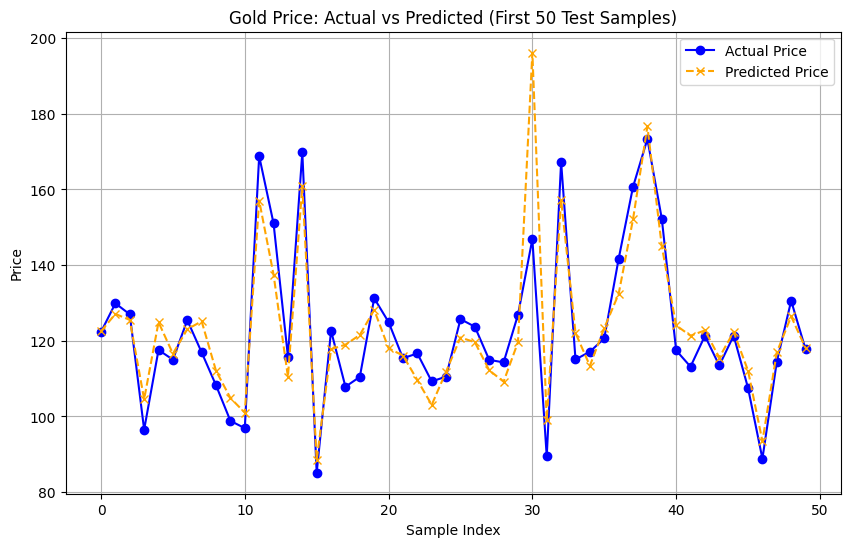

In [21]:
plt.figure(figsize=(10, 6))

plt.plot(y_test.values[0:50], label='Actual Price', color='blue', marker='o')
plt.plot(y_pred[0:50], label='Predicted Price', color='orange', linestyle='--', marker='x')

plt.title("Gold Price: Actual vs Predicted (First 50 Test Samples)")
plt.xlabel("Sample Index")
plt.ylabel("Price")
plt.legend()
plt.grid(True)
plt.show()

The value of R^2 is 0.8976

The model fits the data really well as we have an R^2 score of 0.8976 which indicates that approximately 89.76% of the variance in the Gold Price is explained by the features.

The residual plot shows heteroscedasticity. The variance of the errors increases as the predicted price increases.For lower predicted prices, the residuals are tightly clustered.For higher predicted prices, the residuals spread out significantly.It becomes less precise at predicting higher gold prices.

Silver has the strongest correlation with Gold Price.